**START -> Symptom Severity Analysis -> Medical Prioritization Analysis -> Final Consultation Assignment ->  END**

In [2]:

# Install Required Libraries
!pip install langgraph langchain langchain-google-genai google-generativeai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 815.8 kB/s eta 0:00:00


In [3]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.tools import tool
import os

In [4]:
import os
os.environ["GOOGLE_API_KEY"]="API"

Initialize LLM

In [5]:
llm=ChatGoogleGenerativeAI(
    model='gemini-2.5-flash'
)

In [6]:
# Define Workflow State
class HealthcareState(TypedDict):
    patient_name: str
    age: int
    fever: float
    oxygen_level: int
    heart_rate: int
    symptom_duration: int
    existing_conditions: str

    severity_level: str
    medical_priority: str
    consultation_assignment: str

In [8]:
# Step 1 - Symptom Severity Tool (Version 1 logic)
@tool
def symptom_severity_tool(
    fever: float,
    oxygen_level: int,
    heart_rate: int,
    symptom_duration: int
) -> str:
    """
    Analyze patient symptoms and return severity level.
    """

    if oxygen_level < 90 or fever > 102 or heart_rate > 120:
        return "CRITICAL"
    elif oxygen_level < 95 or fever > 100 or heart_rate > 100 or symptom_duration > 5:
        return "MODERATE"
    else:
        return "STABLE"

In [9]:
# Node 1 - Symptom Severity Analysis
def symptom_severity_analysis(state: HealthcareState) -> HealthcareState:
    result = symptom_severity_tool.invoke({
        "fever": state["fever"],
        "oxygen_level": state["oxygen_level"],
        "heart_rate": state["heart_rate"],
        "symptom_duration": state["symptom_duration"]
    })
    state["severity_level"] = result
    return state


In [10]:
# Node 2 - Gemini Medical Prioritization
def medical_prioritization_analysis(state: HealthcareState) -> HealthcareState:
    prompt = f"""
    You are a hospital medical prioritization assistant.

    Analyze the following patient details:

    Severity Level: {state['severity_level']}
    Patient Age: {state['age']}
    Existing Conditions: {state['existing_conditions']}

    Classification Rules:
    - CRITICAL => EMERGENCY
    - MODERATE + elderly patient (age > 60) or existing conditions => PRIORITY_CONSULTATION
    - STABLE => REGULAR_CONSULTATION

    Return ONLY one of the following:
    EMERGENCY
    PRIORITY_CONSULTATION
    REGULAR_CONSULTATION
    """
    response = llm.invoke(prompt)
    state["medical_priority"] = response.content.strip()
    return state

In [11]:

# Node 3 - Final Consultation Assignment
def final_consultation_assignment(state: HealthcareState) -> HealthcareState:
    if state["medical_priority"] == "EMERGENCY":
        state["consultation_assignment"] = "ICU/ER"
    elif state["medical_priority"] == "PRIORITY_CONSULTATION":
        state["consultation_assignment"] = "Specialist Doctor"
    else:
        state["consultation_assignment"] = "General Physician"
    return state

In [12]:
# Build LangGraph Workflow
graph = StateGraph(HealthcareState)
graph.add_node("symptom_severity_analysis", symptom_severity_analysis)
graph.add_node("medical_prioritization_analysis", medical_prioritization_analysis)
graph.add_node("final_consultation_assignment", final_consultation_assignment)

graph.set_entry_point("symptom_severity_analysis")
graph.add_edge("symptom_severity_analysis", "medical_prioritization_analysis")
graph.add_edge("medical_prioritization_analysis", "final_consultation_assignment")
graph.add_edge("final_consultation_assignment", END)

workflow = graph.compile()


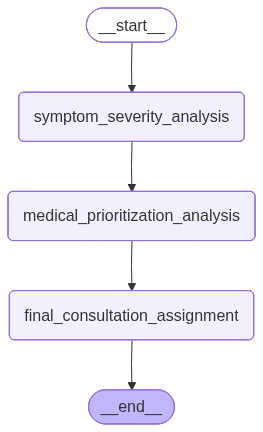

In [13]:
workflow

In [14]:
# Test Input
initial_state: HealthcareState = {
    "patient_name": "Anil Kumar",
    "age": 68,
    "fever": 102.5,
    "oxygen_level": 85,
    "heart_rate": 135,
    "symptom_duration": 6,
    "existing_conditions": "Diabetes, Hypertension"
}

# Execute Workflow
result = workflow.invoke(initial_state)

In [15]:

#Output
print(result)


{'patient_name': 'Anil Kumar', 'age': 68, 'fever': 102.5, 'oxygen_level': 85, 'heart_rate': 135, 'symptom_duration': 6, 'existing_conditions': 'Diabetes, Hypertension', 'severity_level': 'CRITICAL', 'medical_priority': 'EMERGENCY', 'consultation_assignment': 'ICU/ER'}
